## Principe de l'algorithme GRASP:
- Classée comme étant une méthode Hybride qui combine les 2 modes de fonctionnement Construction et amélioration
- Principe de construction : Elle commence par une solution vide et elle la construisent pas à pas à chaque étape on rajoute une valeur à la liste des jobs  , et on vérifie les contraintes du problème (c'est à dire on rajoute le meilleur job parmi la liste des jobs non encore séléctionnées  )
- Principe d'amélioration : la solution qui est en cours de construction (qui est semi complète) itérativement à chaque itération on améliore , elle passe d'une solution à une solution voisine en faisant une recherche locale
- on s'arrete selon un critère d'arret : amélioration(un nombre d'itérations maximal stagnation) & construction(solution complète)

In [ ]:
import random
import numpy as np

# Fonction d'évaluation de la solution (Flowshop)
def evaluate(solution, processing_times):
    n_jobs = len(solution)
    n_machines = len(processing_times[0])
    completion_times = np.zeros((n_jobs, n_machines))

    for j in range(n_jobs):
        job = solution[j]
        for m in range(n_machines):
            if j == 0 and m == 0:
                completion_times[j, m] = processing_times[job][m]
            elif j == 0:
                completion_times[j, m] = completion_times[j, m-1] + processing_times[job][m]
            elif m == 0:
                completion_times[j, m] = completion_times[j-1, m] + processing_times[job][m]
            else:
                completion_times[j, m] = max(completion_times[j-1, m], completion_times[j, m-1]) + processing_times[job][m]

    return completion_times[-1, -1]

# Construction d'une solution initiale
def greedy_randomized_construction(processing_times, alpha):
    n_jobs = len(processing_times)
    candidate_list = list(range(n_jobs))
    solution = []

    while candidate_list:
        min_cost = float('inf')
        max_cost = float('-inf')
        cost_list = []

        for job in candidate_list:
            partial_solution = solution + [job]
            cost = evaluate(partial_solution, processing_times)
            cost_list.append((job, cost))
            min_cost = min(min_cost, cost)
            max_cost = max(max_cost, cost)

        threshold = min_cost + alpha * (max_cost - min_cost)
        restricted_candidate_list = [job for job, cost in cost_list if cost <= threshold]

        selected_job = random.choice(restricted_candidate_list)
        solution.append(selected_job)
        candidate_list.remove(selected_job)

    return solution

# Amélioration locale
def local_search(solution, processing_times):
    n = len(solution)
    best_cost = evaluate(solution, processing_times)
    improved = True

    while improved:
        improved = False
        for i in range(n-1):
            for j in range(i+1, n):
                new_solution = solution[:]
                new_solution[i], new_solution[j] = new_solution[j], new_solution[i]
                new_cost = evaluate(new_solution, processing_times)

                if new_cost < best_cost:
                    solution = new_solution
                    best_cost = new_cost
                    improved = True

    return solution

# Algorithme GRASP
def grasp(processing_times, max_iterations, alpha):
    best_solution = None
    best_cost = float('inf')

    for _ in range(max_iterations):
        solution = greedy_randomized_construction(processing_times, alpha)
        solution = local_search(solution, processing_times)
        cost = evaluate(solution, processing_times)

        if cost < best_cost:
            best_solution = solution
            best_cost = cost

    return best_solution, best_cost


def transpose(matrix):
    rows = len(matrix)
    cols = len(matrix[0])
    transposed_matrix = [[0] * rows for _ in range(cols)]

    for i in range(rows):
        for j in range(cols):
            transposed_matrix[j][i] = matrix[i][j]

    return transposed_matrix

# Fonction de test
def test_grasp():
    A = [
    [77, 94, 9, 57, 29, 79, 55, 73, 65, 86, 25, 39, 76, 24, 38, 5, 91, 29, 22, 27],
    [39, 31, 46, 18, 93, 58, 85, 58, 97, 10, 79, 93, 2, 87, 17, 18, 10, 50, 8, 26],
    [14, 21, 15, 10, 85, 46, 42, 18, 36, 2, 44, 89, 6, 3, 1, 43, 81, 57, 76, 59],
    [11, 2, 36, 30, 89, 10, 88, 22, 31, 9, 43, 91, 26, 3, 75, 99, 63, 83, 70, 84],
    [83, 13, 84, 46, 20, 33, 74, 42, 33, 71, 32, 48, 42, 99, 7, 54, 8, 73, 30, 75]
]

    processing_times = transpose(A)
    print(processing_times)
    max_iterations = 100
    alpha = 0.3

    best_solution, best_cost = grasp(processing_times, max_iterations, alpha)
    print(f'Best solution: {best_solution}')
    print(f'Best cost: {best_cost}')

# Exécuter le test
test_grasp()


[[77, 39, 14, 11, 83], [94, 31, 21, 2, 13], [9, 46, 15, 36, 84], [57, 18, 10, 30, 46], [29, 93, 85, 89, 20], [79, 58, 46, 10, 33], [55, 85, 42, 88, 74], [73, 58, 18, 22, 42], [65, 97, 36, 31, 33], [86, 10, 2, 9, 71], [25, 79, 44, 43, 32], [39, 93, 89, 91, 48], [76, 2, 6, 26, 42], [24, 87, 3, 3, 99], [38, 17, 1, 75, 7], [5, 18, 43, 99, 54], [91, 10, 81, 63, 8], [29, 50, 57, 83, 73], [22, 8, 76, 70, 30], [27, 26, 59, 84, 75]]
Best solution: [2, 15, 13, 18, 19, 0, 11, 4, 9, 5, 6, 10, 12, 17, 8, 14, 7, 3, 16, 1]
Best cost: 1098.0


## Tests:

### Instances 20 * 5

In [ ]:
import numpy as np


# Votre matrice d'origine
A =[
    [54, 83, 15, 71, 77, 36, 53, 38, 27, 87, 76, 91, 14, 29, 12, 77, 32, 87, 68, 94],
    [79, 3, 11, 99, 56, 70, 99, 60, 5, 56, 3, 61, 73, 75, 47, 14, 21, 86, 5, 77],
    [16, 89, 49, 15, 89, 45, 60, 23, 57, 64, 7, 1, 63, 41, 63, 47, 26, 75, 77, 40],
    [66, 58, 31, 68, 78, 91, 13, 59, 49, 85, 85, 9, 39, 41, 56, 40, 54, 77, 51, 31],
    [58, 56, 20, 85, 53, 35, 53, 41, 69, 13, 86, 72, 8, 49, 47, 87, 58, 18, 68, 28]
]




processing_times = transpose(A)
print(processing_times)
max_iterations = 100
alpha = 0.3

best_solution, best_cost = grasp(processing_times, max_iterations, alpha)
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')




[[54, 79, 16, 66, 58], [83, 3, 89, 58, 56], [15, 11, 49, 31, 20], [71, 99, 15, 68, 85], [77, 56, 89, 78, 53], [36, 70, 45, 91, 35], [53, 99, 60, 13, 53], [38, 60, 23, 59, 41], [27, 5, 57, 49, 69], [87, 56, 64, 85, 13], [76, 3, 7, 85, 86], [91, 61, 1, 9, 72], [14, 73, 63, 39, 8], [29, 75, 41, 41, 49], [12, 47, 63, 56, 47], [77, 14, 47, 40, 87], [32, 21, 26, 54, 58], [87, 86, 75, 77, 18], [68, 5, 77, 51, 68], [94, 77, 40, 31, 28]]
Best solution: [2, 14, 3, 4, 0, 8, 17, 6, 16, 11, 10, 18, 5, 1, 12, 7, 15, 13, 9, 19]
Best cost: 1297.0


In [ ]:
#Deviation
UB= 1278
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : 1.486697965571205


In [ ]:
A= [
    [26, 38, 27, 88, 95, 55, 54, 63, 23, 45, 86, 43, 43, 40, 37, 54, 35, 59, 43, 50],
    [59, 62, 44, 10, 23, 64, 47, 68, 54,  9, 30, 31, 92,  7, 14, 95, 76, 82, 91, 37],
    [78, 90, 64, 49, 47, 20, 61, 93, 36, 47, 70, 54, 87, 13, 40, 34, 55, 13, 11,  5],
    [88, 54, 47, 83, 84,  9, 30, 11, 92, 63, 62, 75, 48, 23, 85, 23,  4, 31, 13, 98],
    [69, 30, 61, 35, 53, 98, 94, 33, 77, 31, 54, 71, 78,  9, 79, 51, 76, 56, 80, 72]
]


processing_times = transpose(A)
print(processing_times)
max_iterations = 100
alpha = 0.3

best_solution, best_cost = grasp(processing_times, max_iterations, alpha)
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')




[[26, 59, 78, 88, 69], [38, 62, 90, 54, 30], [27, 44, 64, 47, 61], [88, 10, 49, 83, 35], [95, 23, 47, 84, 53], [55, 64, 20, 9, 98], [54, 47, 61, 30, 94], [63, 68, 93, 11, 33], [23, 54, 36, 92, 77], [45, 9, 47, 63, 31], [86, 30, 70, 62, 54], [43, 31, 54, 75, 71], [43, 92, 87, 48, 78], [40, 7, 13, 23, 9], [37, 14, 40, 85, 79], [54, 95, 34, 23, 51], [35, 76, 55, 4, 76], [59, 82, 13, 31, 56], [43, 91, 11, 13, 80], [50, 37, 5, 98, 72]]
Best solution: [5, 14, 6, 8, 2, 0, 1, 17, 10, 15, 13, 18, 3, 4, 16, 9, 19, 7, 12, 11]
Best cost: 1373.0


In [ ]:
#Deviation
UB= 1359
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : 1.030169242089772


### Instances 20*10

In [ ]:
# 20 * 10
import time
A= [
    [74, 21, 58, 4, 21, 28, 58, 83, 31, 61, 94, 44, 97, 94, 66, 6, 37, 22, 99, 83],
    [28, 3, 27, 61, 34, 76, 64, 87, 54, 98, 76, 41, 70, 43, 42, 79, 88, 15, 49, 72],
    [89, 52, 56, 13, 7, 32, 32, 98, 46, 60, 23, 87, 7, 36, 26, 85, 7, 34, 36, 48],
    [60, 88, 26, 58, 76, 98, 29, 47, 79, 26, 19, 48, 95, 78, 77, 90, 24, 10, 85, 55],
    [54, 66, 12, 57, 70, 82, 99, 84, 16, 41, 23, 11, 68, 58, 30, 5, 5, 39, 58, 31],
    [92, 11, 54, 97, 57, 53, 65, 77, 51, 36, 53, 19, 54, 86, 40, 56, 79, 74, 24, 3],
    [9, 8, 88, 72, 27, 22, 50, 2, 49, 82, 93, 96, 43, 13, 60, 11, 37, 91, 84, 67],
    [4, 18, 25, 28, 95, 51, 84, 18, 6, 90, 69, 61, 57, 5, 75, 4, 38, 28, 4, 80],
    [25, 15, 91, 49, 56, 10, 62, 70, 76, 99, 58, 83, 84, 64, 74, 14, 18, 48, 96, 86],
    [15, 84, 8, 30, 95, 79, 9, 91, 76, 26, 42, 66, 70, 91, 67, 3, 98, 4, 71, 62]
]



processing_times = transpose(A)
print(processing_times)
max_iterations = 100
alpha = 0.3
start_time = time.time()
best_solution, best_cost = grasp(processing_times, max_iterations, alpha)
elapsed_time = time.time() - start_time
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')
print("elapsed time :", elapsed_time)

[[74, 28, 89, 60, 54, 92, 9, 4, 25, 15], [21, 3, 52, 88, 66, 11, 8, 18, 15, 84], [58, 27, 56, 26, 12, 54, 88, 25, 91, 8], [4, 61, 13, 58, 57, 97, 72, 28, 49, 30], [21, 34, 7, 76, 70, 57, 27, 95, 56, 95], [28, 76, 32, 98, 82, 53, 22, 51, 10, 79], [58, 64, 32, 29, 99, 65, 50, 84, 62, 9], [83, 87, 98, 47, 84, 77, 2, 18, 70, 91], [31, 54, 46, 79, 16, 51, 49, 6, 76, 76], [61, 98, 60, 26, 41, 36, 82, 90, 99, 26], [94, 76, 23, 19, 23, 53, 93, 69, 58, 42], [44, 41, 87, 48, 11, 19, 96, 61, 83, 66], [97, 70, 7, 95, 68, 54, 43, 57, 84, 70], [94, 43, 36, 78, 58, 86, 13, 5, 64, 91], [66, 42, 26, 77, 30, 40, 60, 75, 74, 67], [6, 79, 85, 90, 5, 56, 11, 4, 14, 3], [37, 88, 7, 24, 5, 79, 37, 38, 18, 98], [22, 15, 34, 10, 39, 74, 91, 28, 48, 4], [99, 49, 36, 85, 58, 24, 84, 4, 96, 71], [83, 72, 48, 55, 31, 3, 67, 80, 86, 62]]
Best solution: [3, 1, 2, 8, 16, 4, 11, 12, 9, 17, 5, 18, 13, 14, 7, 19, 10, 6, 0, 15]
Best cost: 1619.0
elapsed time : 18.436906814575195


In [ ]:
#Deviation
UB= 1582
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : 2.338811630847029


### Instances 50*5

In [ ]:
import numpy as np
def test_grasp():

# Votre matrice d'origine
    A = [
    [75, 87, 13, 11, 41, 43, 93, 69, 80, 13, 24, 72, 38, 81, 83, 88, 26,  6, 89, 67, 70, 30, 89, 30, 68, 21, 78, 46, 99, 10, 17, 23, 83, 47, 86, 18, 67, 46,  4, 14,  4, 20, 88, 50, 84, 58, 93, 76, 50, 30],
    [26, 37, 25, 95, 49, 12, 59, 17, 46, 20, 52, 44, 92, 75, 95, 33, 10, 45,  2, 62, 62, 82, 29, 29, 94, 20, 42, 80, 94, 35,  8, 41, 65,  4, 71, 30, 14, 32, 50, 30, 27, 98, 39, 84, 65, 12, 58, 45, 49, 15],
    [48,  4, 92, 92, 72, 45,  5, 98, 93, 17, 79, 11, 16, 89, 81, 92, 45, 61, 39, 28, 94, 87, 23,  1, 55, 91, 67, 91,  4, 60, 38, 25, 90, 93, 13, 65, 25, 34, 47, 98, 91, 11, 46, 50, 77,  5, 14, 47, 80, 45],
    [26, 67,  4, 14, 93, 54, 21, 20,  6, 18, 75, 25, 16, 77, 28, 24, 15, 77, 36, 16, 32, 46, 21, 81, 28, 70, 89, 54, 96, 62, 46, 60, 19, 97, 13,  7, 44,  7, 73, 15, 66, 70, 97, 33, 97, 64, 73, 28,  4, 87],
    [77, 94,  9, 57, 29, 79, 55, 73, 65, 86, 25, 39, 76, 24, 38,  5, 91, 29, 22, 27, 39, 31, 46, 18, 93, 58, 85, 58, 97, 10, 79, 93,  2, 87, 17, 18, 10, 50,  8, 26, 14, 21, 15, 10, 85, 46, 42, 18, 36,  2]
]




    processing_times = transpose(A)
    print(processing_times)
    max_iterations = 100
    alpha = 0.3

    best_solution, best_cost = grasp(processing_times, max_iterations, alpha)
    print(f'Best solution: {best_solution}')
    print(f'Best cost: {best_cost}')

# Exécuter le test
test_grasp()


[[75, 26, 48, 26, 77], [87, 37, 4, 67, 94], [13, 25, 92, 4, 9], [11, 95, 92, 14, 57], [41, 49, 72, 93, 29], [43, 12, 45, 54, 79], [93, 59, 5, 21, 55], [69, 17, 98, 20, 73], [80, 46, 93, 6, 65], [13, 20, 17, 18, 86], [24, 52, 79, 75, 25], [72, 44, 11, 25, 39], [38, 92, 16, 16, 76], [81, 75, 89, 77, 24], [83, 95, 81, 28, 38], [88, 33, 92, 24, 5], [26, 10, 45, 15, 91], [6, 45, 61, 77, 29], [89, 2, 39, 36, 22], [67, 62, 28, 16, 27], [70, 62, 94, 32, 39], [30, 82, 87, 46, 31], [89, 29, 23, 21, 46], [30, 29, 1, 81, 18], [68, 94, 55, 28, 93], [21, 20, 91, 70, 58], [78, 42, 67, 89, 85], [46, 80, 91, 54, 58], [99, 94, 4, 96, 97], [10, 35, 60, 62, 10], [17, 8, 38, 46, 79], [23, 41, 25, 60, 93], [83, 65, 90, 19, 2], [47, 4, 93, 97, 87], [86, 71, 13, 13, 17], [18, 30, 65, 7, 18], [67, 14, 25, 44, 10], [46, 32, 34, 7, 50], [4, 50, 47, 73, 8], [14, 30, 98, 15, 26], [4, 27, 91, 66, 14], [20, 98, 11, 70, 21], [88, 39, 46, 97, 15], [50, 84, 50, 33, 10], [84, 65, 77, 97, 85], [58, 12, 5, 64, 46], [93, 5

In [ ]:
#50*5

A = [
    [75, 87, 13, 11, 41, 43, 93, 69, 80, 13, 24, 72, 38, 81, 83, 88, 26,  6, 89, 67, 70, 30, 89, 30, 68, 21, 78, 46, 99, 10, 17, 23, 83, 47, 86, 18, 67, 46,  4, 14,  4, 20, 88, 50, 84, 58, 93, 76, 50, 30],
    [26, 37, 25, 95, 49, 12, 59, 17, 46, 20, 52, 44, 92, 75, 95, 33, 10, 45,  2, 62, 62, 82, 29, 29, 94, 20, 42, 80, 94, 35,  8, 41, 65,  4, 71, 30, 14, 32, 50, 30, 27, 98, 39, 84, 65, 12, 58, 45, 49, 15],
    [48,  4, 92, 92, 72, 45,  5, 98, 93, 17, 79, 11, 16, 89, 81, 92, 45, 61, 39, 28, 94, 87, 23,  1, 55, 91, 67, 91,  4, 60, 38, 25, 90, 93, 13, 65, 25, 34, 47, 98, 91, 11, 46, 50, 77,  5, 14, 47, 80, 45],
    [26, 67,  4, 14, 93, 54, 21, 20,  6, 18, 75, 25, 16, 77, 28, 24, 15, 77, 36, 16, 32, 46, 21, 81, 28, 70, 89, 54, 96, 62, 46, 60, 19, 97, 13,  7, 44,  7, 73, 15, 66, 70, 97, 33, 97, 64, 73, 28,  4, 87],
    [77, 94,  9, 57, 29, 79, 55, 73, 65, 86, 25, 39, 76, 24, 38,  5, 91, 29, 22, 27, 39, 31, 46, 18, 93, 58, 85, 58, 97, 10, 79, 93,  2, 87, 17, 18, 10, 50,  8, 26, 14, 21, 15, 10, 85, 46, 42, 18, 36,  2]
]
processing_times = transpose(A)
print(processing_times)
max_iterations = 100
alpha = 0.3
start_time = time.time()
best_solution, best_cost = grasp(processing_times, max_iterations, alpha)
elapsed_time = time.time() - start_time
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')
print("elapsed time :", elapsed_time)

[[75, 26, 48, 26, 77], [87, 37, 4, 67, 94], [13, 25, 92, 4, 9], [11, 95, 92, 14, 57], [41, 49, 72, 93, 29], [43, 12, 45, 54, 79], [93, 59, 5, 21, 55], [69, 17, 98, 20, 73], [80, 46, 93, 6, 65], [13, 20, 17, 18, 86], [24, 52, 79, 75, 25], [72, 44, 11, 25, 39], [38, 92, 16, 16, 76], [81, 75, 89, 77, 24], [83, 95, 81, 28, 38], [88, 33, 92, 24, 5], [26, 10, 45, 15, 91], [6, 45, 61, 77, 29], [89, 2, 39, 36, 22], [67, 62, 28, 16, 27], [70, 62, 94, 32, 39], [30, 82, 87, 46, 31], [89, 29, 23, 21, 46], [30, 29, 1, 81, 18], [68, 94, 55, 28, 93], [21, 20, 91, 70, 58], [78, 42, 67, 89, 85], [46, 80, 91, 54, 58], [99, 94, 4, 96, 97], [10, 35, 60, 62, 10], [17, 8, 38, 46, 79], [23, 41, 25, 60, 93], [83, 65, 90, 19, 2], [47, 4, 93, 97, 87], [86, 71, 13, 13, 17], [18, 30, 65, 7, 18], [67, 14, 25, 44, 10], [46, 32, 34, 7, 50], [4, 50, 47, 73, 8], [14, 30, 98, 15, 26], [4, 27, 91, 66, 14], [20, 98, 11, 70, 21], [88, 39, 46, 97, 15], [50, 84, 50, 33, 10], [84, 65, 77, 97, 85], [58, 12, 5, 64, 46], [93, 5

In [ ]:
#Deviation
UB=  2724
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : 0.18355359765051393


### Instances 100*5




In [ ]:
#100*5
matrix = [
    [73, 84, 57, 52, 66, 67, 33, 62, 65, 7, 6, 31, 42, 82, 48, 45, 79, 86, 10, 47, 67, 86, 64, 38, 13, 69, 4, 21, 25, 74, 11, 85, 50, 21, 93, 98, 91, 26, 4, 28, 61, 8, 55, 68, 30, 26, 81, 95, 49, 6, 82, 71, 61, 84, 29, 44, 83, 12, 54, 19, 52, 59, 74, 42, 60, 43, 80, 34, 74, 46, 40, 27, 79, 1, 98, 44, 8, 55, 55, 27, 69, 79, 97, 39, 54, 75, 88, 87, 97, 4, 79, 59, 7, 89, 61, 42, 79, 85, 66, 99],
    [34, 46, 97, 88, 52, 49, 88, 15, 55, 6, 77, 49, 46, 14, 35, 40, 1, 70, 46, 28, 73, 24, 44, 55, 94, 52, 40, 76, 92, 22, 46, 19, 18, 50, 31, 41, 51, 73, 22, 21, 79, 93, 98, 89, 44, 64, 93, 66, 14, 10, 36, 36, 69, 79, 90, 51, 81, 16, 28, 26, 97, 33, 77, 68, 28, 46, 16, 96, 59, 56, 4, 52, 89, 84, 42, 37, 90, 51, 84, 16, 39, 16, 37, 19, 15, 68, 7, 58, 47, 27, 82, 72, 1, 7, 22, 40, 59, 16, 7, 72],
    [8, 37, 38, 30, 20, 68, 4, 78, 41, 2, 62, 38, 95, 82, 96, 56, 61, 34, 1, 9, 57, 80, 58, 7, 56, 31, 92, 84, 25, 20, 65, 36, 67, 96, 35, 59, 76, 66, 83, 37, 33, 2, 95, 20, 84, 43, 4, 44, 74, 92, 55, 98, 8, 30, 18, 28, 54, 68, 42, 28, 12, 57, 81, 19, 16, 88, 75, 11, 57, 99, 4, 51, 26, 6, 16, 71, 52, 96, 89, 79, 91, 57, 2, 33, 42, 1, 40, 76, 85, 99, 65, 98, 78, 61, 83, 30, 14, 62, 41, 91],
    [62, 86, 46, 3, 22, 33, 90, 94, 98, 9, 84, 69, 26, 22, 49, 90, 81, 12, 54, 53, 18, 56, 43, 50, 82, 18, 89, 49, 20, 76, 90, 64, 89, 16, 3, 12, 45, 67, 97, 80, 97, 92, 56, 50, 95, 25, 52, 21, 47, 4, 67, 62, 63, 25, 3, 55, 87, 84, 28, 73, 8, 38, 80, 53, 70, 9, 87, 33, 11, 65, 92, 34, 64, 96, 67, 54, 26, 32, 10, 91, 90, 31, 7, 6, 77, 91, 42, 5, 46, 54, 56, 1, 24, 62, 47, 63, 39, 63, 95, 45],
    [10, 60, 34, 96, 79, 62, 6, 15, 94, 39, 85, 17, 55, 59, 48, 11, 63, 98, 33, 49, 41, 82, 12, 61, 94, 80, 84, 18, 68, 6, 98, 47, 6, 55, 73, 70, 56, 46, 50, 90, 89, 88, 50, 99, 41, 36, 16, 84, 98, 44, 42, 43, 62, 49, 22, 16, 14, 55, 45, 20, 35, 89, 7, 64, 36, 5, 63, 8, 76, 95, 40, 51, 98, 77, 92, 35, 3, 56, 1, 17, 70, 45, 87, 37, 70, 84, 69, 7, 5, 97, 47, 12, 54, 84, 49, 89, 86, 37, 52, 85]
]

processing_times = transpose(A)
print(processing_times)
max_iterations = 100
alpha = 0.3
start_time = time.time()
best_solution, best_cost = grasp(processing_times, max_iterations, alpha)
elapsed_time = time.time() - start_time
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')
print("elapsed time :", elapsed_time)

[[75, 26, 48, 26, 77], [87, 37, 4, 67, 94], [13, 25, 92, 4, 9], [11, 95, 92, 14, 57], [41, 49, 72, 93, 29], [43, 12, 45, 54, 79], [93, 59, 5, 21, 55], [69, 17, 98, 20, 73], [80, 46, 93, 6, 65], [13, 20, 17, 18, 86], [24, 52, 79, 75, 25], [72, 44, 11, 25, 39], [38, 92, 16, 16, 76], [81, 75, 89, 77, 24], [83, 95, 81, 28, 38], [88, 33, 92, 24, 5], [26, 10, 45, 15, 91], [6, 45, 61, 77, 29], [89, 2, 39, 36, 22], [67, 62, 28, 16, 27], [70, 62, 94, 32, 39], [30, 82, 87, 46, 31], [89, 29, 23, 21, 46], [30, 29, 1, 81, 18], [68, 94, 55, 28, 93], [21, 20, 91, 70, 58], [78, 42, 67, 89, 85], [46, 80, 91, 54, 58], [99, 94, 4, 96, 97], [10, 35, 60, 62, 10], [17, 8, 38, 46, 79], [23, 41, 25, 60, 93], [83, 65, 90, 19, 2], [47, 4, 93, 97, 87], [86, 71, 13, 13, 17], [18, 30, 65, 7, 18], [67, 14, 25, 44, 10], [46, 32, 34, 7, 50], [4, 50, 47, 73, 8], [14, 30, 98, 15, 26], [4, 27, 91, 66, 14], [20, 98, 11, 70, 21], [88, 39, 46, 97, 15], [50, 84, 50, 33, 10], [84, 65, 77, 97, 85], [58, 12, 5, 64, 46], [93, 5

In [ ]:
#Deviation
UB=  5493
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : -50.40961223375204


## Hyperheuristique AG des GRASP

In [ ]:
import random
import numpy as np

# Fonction d'évaluation de la solution (Flowshop)
def evaluate(solution, processing_times):
    n_jobs = len(solution)
    n_machines = len(processing_times[0])
    completion_times = np.zeros((n_jobs, n_machines))

    for j in range(n_jobs):
        job = solution[j]
        for m in range(n_machines):
            if j == 0 and m == 0:
                completion_times[j, m] = processing_times[job][m]
            elif j == 0:
                completion_times[j, m] = completion_times[j, m-1] + processing_times[job][m]
            elif m == 0:
                completion_times[j, m] = completion_times[j-1, m] + processing_times[job][m]
            else:
                completion_times[j, m] = max(completion_times[j-1, m], completion_times[j, m-1]) + processing_times[job][m]

    return completion_times[-1, -1]

# Construction d'une solution initiale
def greedy_randomized_construction(processing_times, alpha):
    n_jobs = len(processing_times)
    candidate_list = list(range(n_jobs))
    solution = []

    while candidate_list:
        min_cost = float('inf')
        max_cost = float('-inf')
        cost_list = []

        for job in candidate_list:
            partial_solution = solution + [job]
            cost = evaluate(partial_solution, processing_times)
            cost_list.append((job, cost))
            min_cost = min(min_cost, cost)
            max_cost = max(max_cost, cost)

        threshold = min_cost + alpha * (max_cost - min_cost)
        restricted_candidate_list = [job for job, cost in cost_list if cost <= threshold]

        selected_job = random.choice(restricted_candidate_list)
        solution.append(selected_job)
        candidate_list.remove(selected_job)

    return solution

# Amélioration locale
def local_search(solution, processing_times):
    n = len(solution)
    best_cost = evaluate(solution, processing_times)
    improved = True

    while improved:
        improved = False
        for i in range(n-1):
            for j in range(i+1, n):
                new_solution = solution[:]
                new_solution[i], new_solution[j] = new_solution[j], new_solution[i]
                new_cost = evaluate(new_solution, processing_times)

                if new_cost < best_cost:
                    solution = new_solution
                    best_cost = new_cost
                    improved = True

    return solution

# Algorithme GRASP
def grasp(processing_times, max_iterations, alpha):
    best_solution = None
    best_cost = float('inf')

    for _ in range(max_iterations):
        solution = greedy_randomized_construction(processing_times, alpha)
        solution = local_search(solution, processing_times)
        cost = evaluate(solution, processing_times)

        if cost < best_cost:
            best_solution = solution
            best_cost = cost

    return best_solution, best_cost

# Algorithme Génétique utilisant GRASP
def genetic_algorithm_with_grasp(processing_times, population_size, generations, crossover_rate, mutation_rate, max_iterations_grasp, alpha_grasp):
    # Initialisation de la population avec GRASP
    population = [grasp(processing_times, max_iterations_grasp, alpha_grasp)[0] for _ in range(population_size)]

    def evaluate_population(pop):
        return [evaluate(individual, processing_times) for individual in pop]

    def selection(pop, scores, k=3):
        selected = random.choices(pop, k=k, weights=[1/s for s in scores])
        return min(selected, key=lambda ind: evaluate(ind, processing_times))

    def crossover(parent1, parent2):
        point = random.randint(1, len(parent1) - 2)
        child1 = parent1[:point] + [job for job in parent2 if job not in parent1[:point]]
        child2 = parent2[:point] + [job for job in parent1 if job not in parent2[:point]]
        return child1, child2

    def mutate(individual):
        if random.random() < mutation_rate:
            return grasp(processing_times, max_iterations_grasp, alpha_grasp)[0]
        return individual

    # Boucle principale de l'AG
    for gen in range(generations):
        scores = evaluate_population(population)
        new_population = []

        for _ in range(population_size // 2):
            parent1 = selection(population, scores)
            parent2 = selection(population, scores)

            if random.random() < crossover_rate:
                child1, child2 = crossover(parent1, parent2)
            else:
                child1, child2 = parent1, parent2

            child1 = mutate(child1)
            child2 = mutate(child2)

            new_population.extend([child1, child2])

        population = new_population

    scores = evaluate_population(population)
    best_index = np.argmin(scores)

    return population[best_index], scores[best_index]

# Fonction de test
def test_genetic_algorithm_with_grasp():
    A = [
    [77, 94, 9, 57, 29, 79, 55, 73, 65, 86, 25, 39, 76, 24, 38, 5, 91, 29, 22, 27],
    [39, 31, 46, 18, 93, 58, 85, 58, 97, 10, 79, 93, 2, 87, 17, 18, 10, 50, 8, 26],
    [14, 21, 15, 10, 85, 46, 42, 18, 36, 2, 44, 89, 6, 3, 1, 43, 81, 57, 76, 59],
    [11, 2, 36, 30, 89, 10, 88, 22, 31, 9, 43, 91, 26, 3, 75, 99, 63, 83, 70, 84],
    [83, 13, 84, 46, 20, 33, 74, 42, 33, 71, 32, 48, 42, 99, 7, 54, 8, 73, 30, 75]
]

    processing_times = transpose(A)

    population_size = 10
    generations = 5
    crossover_rate = 0.8
    mutation_rate = 0.2
    max_iterations_grasp = 10
    alpha_grasp = 0.3

    best_solution, best_cost = genetic_algorithm_with_grasp(processing_times, population_size, generations, crossover_rate, mutation_rate, max_iterations_grasp, alpha_grasp)
    print(f'Best solution: {best_solution}')
    print(f'Best cost: {best_cost}')

# Exécuter le test
test_genetic_algorithm_with_grasp()


Best solution: [2, 15, 0, 19, 17, 13, 18, 6, 16, 11, 8, 9, 4, 5, 12, 10, 3, 7, 14, 1]
Best cost: 1098.0


In [ ]:
population_size = 10
generations = 5
crossover_rate = 0.8
mutation_rate = 0.2
max_iterations_grasp = 10
alpha_grasp = 0.3

# Tests

### Instance 20*5

In [ ]:
A =[
    [54, 83, 15, 71, 77, 36, 53, 38, 27, 87, 76, 91, 14, 29, 12, 77, 32, 87, 68, 94],
    [79, 3, 11, 99, 56, 70, 99, 60, 5, 56, 3, 61, 73, 75, 47, 14, 21, 86, 5, 77],
    [16, 89, 49, 15, 89, 45, 60, 23, 57, 64, 7, 1, 63, 41, 63, 47, 26, 75, 77, 40],
    [66, 58, 31, 68, 78, 91, 13, 59, 49, 85, 85, 9, 39, 41, 56, 40, 54, 77, 51, 31],
    [58, 56, 20, 85, 53, 35, 53, 41, 69, 13, 86, 72, 8, 49, 47, 87, 58, 18, 68, 28]
]




processing_times = transpose(A)
print(processing_times)


start_time = time.time()
best_solution, best_cost = genetic_algorithm_with_grasp(processing_times, population_size, generations, crossover_rate, mutation_rate, max_iterations_grasp, alpha_grasp)
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')
elapsed_time = time.time() - start_time

print("elapsed time :", elapsed_time)


[[54, 79, 16, 66, 58], [83, 3, 89, 58, 56], [15, 11, 49, 31, 20], [71, 99, 15, 68, 85], [77, 56, 89, 78, 53], [36, 70, 45, 91, 35], [53, 99, 60, 13, 53], [38, 60, 23, 59, 41], [27, 5, 57, 49, 69], [87, 56, 64, 85, 13], [76, 3, 7, 85, 86], [91, 61, 1, 9, 72], [14, 73, 63, 39, 8], [29, 75, 41, 41, 49], [12, 47, 63, 56, 47], [77, 14, 47, 40, 87], [32, 21, 26, 54, 58], [87, 86, 75, 77, 18], [68, 5, 77, 51, 68], [94, 77, 40, 31, 28]]
Best solution: [2, 10, 14, 5, 12, 8, 3, 15, 17, 18, 0, 7, 1, 16, 13, 4, 6, 9, 19, 11]
Best cost: 1291.0
elapsed time : 13.02253794670105


In [ ]:
#Deviation
UB= 1278
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : 1.0172143974960877


In [ ]:
A= [
    [26, 38, 27, 88, 95, 55, 54, 63, 23, 45, 86, 43, 43, 40, 37, 54, 35, 59, 43, 50],
    [59, 62, 44, 10, 23, 64, 47, 68, 54,  9, 30, 31, 92,  7, 14, 95, 76, 82, 91, 37],
    [78, 90, 64, 49, 47, 20, 61, 93, 36, 47, 70, 54, 87, 13, 40, 34, 55, 13, 11,  5],
    [88, 54, 47, 83, 84,  9, 30, 11, 92, 63, 62, 75, 48, 23, 85, 23,  4, 31, 13, 98],
    [69, 30, 61, 35, 53, 98, 94, 33, 77, 31, 54, 71, 78,  9, 79, 51, 76, 56, 80, 72]
]


processing_times = transpose(A)
print(processing_times)


start_time = time.time()
best_solution, best_cost = genetic_algorithm_with_grasp(processing_times, population_size, generations, crossover_rate, mutation_rate, max_iterations_grasp, alpha_grasp)
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')
elapsed_time = time.time() - start_time

print("elapsed time :", elapsed_time)

[[26, 59, 78, 88, 69], [38, 62, 90, 54, 30], [27, 44, 64, 47, 61], [88, 10, 49, 83, 35], [95, 23, 47, 84, 53], [55, 64, 20, 9, 98], [54, 47, 61, 30, 94], [63, 68, 93, 11, 33], [23, 54, 36, 92, 77], [45, 9, 47, 63, 31], [86, 30, 70, 62, 54], [43, 31, 54, 75, 71], [43, 92, 87, 48, 78], [40, 7, 13, 23, 9], [37, 14, 40, 85, 79], [54, 95, 34, 23, 51], [35, 76, 55, 4, 76], [59, 82, 13, 31, 56], [43, 91, 11, 13, 80], [50, 37, 5, 98, 72]]
Best solution: [5, 19, 6, 8, 14, 0, 18, 4, 1, 7, 13, 17, 9, 2, 12, 11, 10, 16, 3, 15]
Best cost: 1368.0
elapsed time : 10.372373342514038


In [ ]:
#Deviation
UB= 1359
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : 0.6622516556291391




### Instance 20*10

In [ ]:
# 20 * 10
import time
A= [
    [74, 21, 58, 4, 21, 28, 58, 83, 31, 61, 94, 44, 97, 94, 66, 6, 37, 22, 99, 83],
    [28, 3, 27, 61, 34, 76, 64, 87, 54, 98, 76, 41, 70, 43, 42, 79, 88, 15, 49, 72],
    [89, 52, 56, 13, 7, 32, 32, 98, 46, 60, 23, 87, 7, 36, 26, 85, 7, 34, 36, 48],
    [60, 88, 26, 58, 76, 98, 29, 47, 79, 26, 19, 48, 95, 78, 77, 90, 24, 10, 85, 55],
    [54, 66, 12, 57, 70, 82, 99, 84, 16, 41, 23, 11, 68, 58, 30, 5, 5, 39, 58, 31],
    [92, 11, 54, 97, 57, 53, 65, 77, 51, 36, 53, 19, 54, 86, 40, 56, 79, 74, 24, 3],
    [9, 8, 88, 72, 27, 22, 50, 2, 49, 82, 93, 96, 43, 13, 60, 11, 37, 91, 84, 67],
    [4, 18, 25, 28, 95, 51, 84, 18, 6, 90, 69, 61, 57, 5, 75, 4, 38, 28, 4, 80],
    [25, 15, 91, 49, 56, 10, 62, 70, 76, 99, 58, 83, 84, 64, 74, 14, 18, 48, 96, 86],
    [15, 84, 8, 30, 95, 79, 9, 91, 76, 26, 42, 66, 70, 91, 67, 3, 98, 4, 71, 62]
]

processing_times = transpose(A)
print(processing_times)


start_time = time.time()
best_solution, best_cost = genetic_algorithm_with_grasp(processing_times, population_size, generations, crossover_rate, mutation_rate, max_iterations_grasp, alpha_grasp)
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')
elapsed_time = time.time() - start_time

print("elapsed time :", elapsed_time)

[[74, 28, 89, 60, 54, 92, 9, 4, 25, 15], [21, 3, 52, 88, 66, 11, 8, 18, 15, 84], [58, 27, 56, 26, 12, 54, 88, 25, 91, 8], [4, 61, 13, 58, 57, 97, 72, 28, 49, 30], [21, 34, 7, 76, 70, 57, 27, 95, 56, 95], [28, 76, 32, 98, 82, 53, 22, 51, 10, 79], [58, 64, 32, 29, 99, 65, 50, 84, 62, 9], [83, 87, 98, 47, 84, 77, 2, 18, 70, 91], [31, 54, 46, 79, 16, 51, 49, 6, 76, 76], [61, 98, 60, 26, 41, 36, 82, 90, 99, 26], [94, 76, 23, 19, 23, 53, 93, 69, 58, 42], [44, 41, 87, 48, 11, 19, 96, 61, 83, 66], [97, 70, 7, 95, 68, 54, 43, 57, 84, 70], [94, 43, 36, 78, 58, 86, 13, 5, 64, 91], [66, 42, 26, 77, 30, 40, 60, 75, 74, 67], [6, 79, 85, 90, 5, 56, 11, 4, 14, 3], [37, 88, 7, 24, 5, 79, 37, 38, 18, 98], [22, 15, 34, 10, 39, 74, 91, 28, 48, 4], [99, 49, 36, 85, 58, 24, 84, 4, 96, 71], [83, 72, 48, 55, 31, 3, 67, 80, 86, 62]]
Best solution: [4, 8, 2, 3, 17, 1, 13, 11, 16, 7, 12, 14, 9, 10, 5, 18, 19, 6, 0, 15]
Best cost: 1608.0
elapsed time : 31.485293865203857


In [ ]:
#Deviation
UB= 1582
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : 1.643489254108723


### Instance 50*5

In [ ]:
#50*5

A = [
    [75, 87, 13, 11, 41, 43, 93, 69, 80, 13, 24, 72, 38, 81, 83, 88, 26,  6, 89, 67, 70, 30, 89, 30, 68, 21, 78, 46, 99, 10, 17, 23, 83, 47, 86, 18, 67, 46,  4, 14,  4, 20, 88, 50, 84, 58, 93, 76, 50, 30],
    [26, 37, 25, 95, 49, 12, 59, 17, 46, 20, 52, 44, 92, 75, 95, 33, 10, 45,  2, 62, 62, 82, 29, 29, 94, 20, 42, 80, 94, 35,  8, 41, 65,  4, 71, 30, 14, 32, 50, 30, 27, 98, 39, 84, 65, 12, 58, 45, 49, 15],
    [48,  4, 92, 92, 72, 45,  5, 98, 93, 17, 79, 11, 16, 89, 81, 92, 45, 61, 39, 28, 94, 87, 23,  1, 55, 91, 67, 91,  4, 60, 38, 25, 90, 93, 13, 65, 25, 34, 47, 98, 91, 11, 46, 50, 77,  5, 14, 47, 80, 45],
    [26, 67,  4, 14, 93, 54, 21, 20,  6, 18, 75, 25, 16, 77, 28, 24, 15, 77, 36, 16, 32, 46, 21, 81, 28, 70, 89, 54, 96, 62, 46, 60, 19, 97, 13,  7, 44,  7, 73, 15, 66, 70, 97, 33, 97, 64, 73, 28,  4, 87],
    [77, 94,  9, 57, 29, 79, 55, 73, 65, 86, 25, 39, 76, 24, 38,  5, 91, 29, 22, 27, 39, 31, 46, 18, 93, 58, 85, 58, 97, 10, 79, 93,  2, 87, 17, 18, 10, 50,  8, 26, 14, 21, 15, 10, 85, 46, 42, 18, 36,  2]
]
processing_times = transpose(A)
print(processing_times)


start_time = time.time()
best_solution, best_cost = genetic_algorithm_with_grasp(processing_times, population_size, generations, crossover_rate, mutation_rate, max_iterations_grasp, alpha_grasp)
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')
elapsed_time = time.time() - start_time

print("elapsed time :", elapsed_time)

[[75, 26, 48, 26, 77], [87, 37, 4, 67, 94], [13, 25, 92, 4, 9], [11, 95, 92, 14, 57], [41, 49, 72, 93, 29], [43, 12, 45, 54, 79], [93, 59, 5, 21, 55], [69, 17, 98, 20, 73], [80, 46, 93, 6, 65], [13, 20, 17, 18, 86], [24, 52, 79, 75, 25], [72, 44, 11, 25, 39], [38, 92, 16, 16, 76], [81, 75, 89, 77, 24], [83, 95, 81, 28, 38], [88, 33, 92, 24, 5], [26, 10, 45, 15, 91], [6, 45, 61, 77, 29], [89, 2, 39, 36, 22], [67, 62, 28, 16, 27], [70, 62, 94, 32, 39], [30, 82, 87, 46, 31], [89, 29, 23, 21, 46], [30, 29, 1, 81, 18], [68, 94, 55, 28, 93], [21, 20, 91, 70, 58], [78, 42, 67, 89, 85], [46, 80, 91, 54, 58], [99, 94, 4, 96, 97], [10, 35, 60, 62, 10], [17, 8, 38, 46, 79], [23, 41, 25, 60, 93], [83, 65, 90, 19, 2], [47, 4, 93, 97, 87], [86, 71, 13, 13, 17], [18, 30, 65, 7, 18], [67, 14, 25, 44, 10], [46, 32, 34, 7, 50], [4, 50, 47, 73, 8], [14, 30, 98, 15, 26], [4, 27, 91, 66, 14], [20, 98, 11, 70, 21], [88, 39, 46, 97, 15], [50, 84, 50, 33, 10], [84, 65, 77, 97, 85], [58, 12, 5, 64, 46], [93, 5

In [ ]:
#Deviation
UB=  2724
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : 0.18355359765051393


In [ ]:
#100*5
matrix = [
    [73, 84, 57, 52, 66, 67, 33, 62, 65, 7, 6, 31, 42, 82, 48, 45, 79, 86, 10, 47, 67, 86, 64, 38, 13, 69, 4, 21, 25, 74, 11, 85, 50, 21, 93, 98, 91, 26, 4, 28, 61, 8, 55, 68, 30, 26, 81, 95, 49, 6, 82, 71, 61, 84, 29, 44, 83, 12, 54, 19, 52, 59, 74, 42, 60, 43, 80, 34, 74, 46, 40, 27, 79, 1, 98, 44, 8, 55, 55, 27, 69, 79, 97, 39, 54, 75, 88, 87, 97, 4, 79, 59, 7, 89, 61, 42, 79, 85, 66, 99],
    [34, 46, 97, 88, 52, 49, 88, 15, 55, 6, 77, 49, 46, 14, 35, 40, 1, 70, 46, 28, 73, 24, 44, 55, 94, 52, 40, 76, 92, 22, 46, 19, 18, 50, 31, 41, 51, 73, 22, 21, 79, 93, 98, 89, 44, 64, 93, 66, 14, 10, 36, 36, 69, 79, 90, 51, 81, 16, 28, 26, 97, 33, 77, 68, 28, 46, 16, 96, 59, 56, 4, 52, 89, 84, 42, 37, 90, 51, 84, 16, 39, 16, 37, 19, 15, 68, 7, 58, 47, 27, 82, 72, 1, 7, 22, 40, 59, 16, 7, 72],
    [8, 37, 38, 30, 20, 68, 4, 78, 41, 2, 62, 38, 95, 82, 96, 56, 61, 34, 1, 9, 57, 80, 58, 7, 56, 31, 92, 84, 25, 20, 65, 36, 67, 96, 35, 59, 76, 66, 83, 37, 33, 2, 95, 20, 84, 43, 4, 44, 74, 92, 55, 98, 8, 30, 18, 28, 54, 68, 42, 28, 12, 57, 81, 19, 16, 88, 75, 11, 57, 99, 4, 51, 26, 6, 16, 71, 52, 96, 89, 79, 91, 57, 2, 33, 42, 1, 40, 76, 85, 99, 65, 98, 78, 61, 83, 30, 14, 62, 41, 91],
    [62, 86, 46, 3, 22, 33, 90, 94, 98, 9, 84, 69, 26, 22, 49, 90, 81, 12, 54, 53, 18, 56, 43, 50, 82, 18, 89, 49, 20, 76, 90, 64, 89, 16, 3, 12, 45, 67, 97, 80, 97, 92, 56, 50, 95, 25, 52, 21, 47, 4, 67, 62, 63, 25, 3, 55, 87, 84, 28, 73, 8, 38, 80, 53, 70, 9, 87, 33, 11, 65, 92, 34, 64, 96, 67, 54, 26, 32, 10, 91, 90, 31, 7, 6, 77, 91, 42, 5, 46, 54, 56, 1, 24, 62, 47, 63, 39, 63, 95, 45],
    [10, 60, 34, 96, 79, 62, 6, 15, 94, 39, 85, 17, 55, 59, 48, 11, 63, 98, 33, 49, 41, 82, 12, 61, 94, 80, 84, 18, 68, 6, 98, 47, 6, 55, 73, 70, 56, 46, 50, 90, 89, 88, 50, 99, 41, 36, 16, 84, 98, 44, 42, 43, 62, 49, 22, 16, 14, 55, 45, 20, 35, 89, 7, 64, 36, 5, 63, 8, 76, 95, 40, 51, 98, 77, 92, 35, 3, 56, 1, 17, 70, 45, 87, 37, 70, 84, 69, 7, 5, 97, 47, 12, 54, 84, 49, 89, 86, 37, 52, 85]
]

processing_times = transpose(A)
print(processing_times)


start_time = time.time()
best_solution, best_cost = genetic_algorithm_with_grasp(processing_times, population_size, generations, crossover_rate, mutation_rate, max_iterations_grasp, alpha_grasp)
print(f'Best solution: {best_solution}')
print(f'Best cost: {best_cost}')
elapsed_time = time.time() - start_time

print("elapsed time :", elapsed_time)


[[75, 26, 48, 26, 77], [87, 37, 4, 67, 94], [13, 25, 92, 4, 9], [11, 95, 92, 14, 57], [41, 49, 72, 93, 29], [43, 12, 45, 54, 79], [93, 59, 5, 21, 55], [69, 17, 98, 20, 73], [80, 46, 93, 6, 65], [13, 20, 17, 18, 86], [24, 52, 79, 75, 25], [72, 44, 11, 25, 39], [38, 92, 16, 16, 76], [81, 75, 89, 77, 24], [83, 95, 81, 28, 38], [88, 33, 92, 24, 5], [26, 10, 45, 15, 91], [6, 45, 61, 77, 29], [89, 2, 39, 36, 22], [67, 62, 28, 16, 27], [70, 62, 94, 32, 39], [30, 82, 87, 46, 31], [89, 29, 23, 21, 46], [30, 29, 1, 81, 18], [68, 94, 55, 28, 93], [21, 20, 91, 70, 58], [78, 42, 67, 89, 85], [46, 80, 91, 54, 58], [99, 94, 4, 96, 97], [10, 35, 60, 62, 10], [17, 8, 38, 46, 79], [23, 41, 25, 60, 93], [83, 65, 90, 19, 2], [47, 4, 93, 97, 87], [86, 71, 13, 13, 17], [18, 30, 65, 7, 18], [67, 14, 25, 44, 10], [46, 32, 34, 7, 50], [4, 50, 47, 73, 8], [14, 30, 98, 15, 26], [4, 27, 91, 66, 14], [20, 98, 11, 70, 21], [88, 39, 46, 97, 15], [50, 84, 50, 33, 10], [84, 65, 77, 97, 85], [58, 12, 5, 64, 46], [93, 5

In [ ]:
#Deviation
UB=  5493
D = (( best_cost - UB )/UB)*100
print(f'Deviation : {D}')

Deviation : -50.40961223375204


# Visualisation

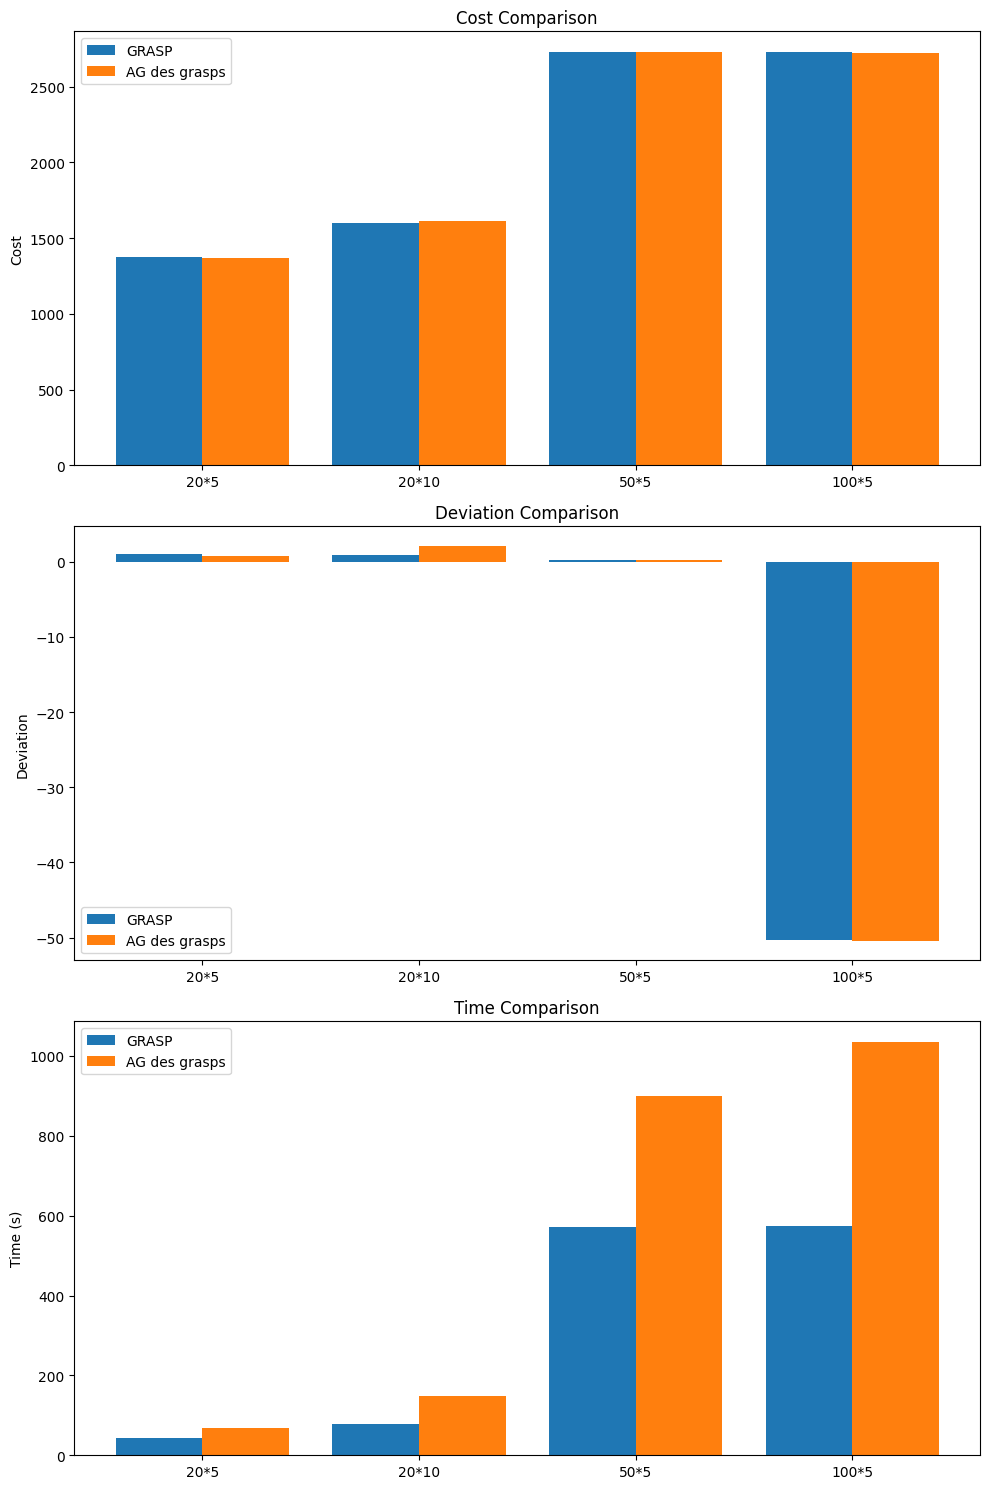

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
instances = ['20*5', '20*10', '50*5', '100*5']
grasp_costs = [1373, 1597, 2729, 2729]
grasp_deviations = [1.03, 0.94, 0.18, -50.31]
grasp_times = [42.88, 78.94, 570.38, 573.99]
ag_costs = [1370, 1615, 2729, 2724]
ag_deviations = [0.8, 2.08, 0.18, -50.4]
ag_times = [69.32, 147.72, 898.97, 1034.69]

# Create subplots
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

# Plot cost comparison
axs[0].bar(np.arange(len(instances)) - 0.2, grasp_costs, 0.4, label='GRASP')
axs[0].bar(np.arange(len(instances)) + 0.2, ag_costs, 0.4, label='AG des grasps')
axs[0].set_title('Cost Comparison')
axs[0].set_xticks(np.arange(len(instances)))
axs[0].set_xticklabels(instances)
axs[0].set_ylabel('Cost')
axs[0].legend()

# Plot deviation comparison
axs[1].bar(np.arange(len(instances)) - 0.2, grasp_deviations, 0.4, label='GRASP')
axs[1].bar(np.arange(len(instances)) + 0.2, ag_deviations, 0.4, label='AG des grasps')
axs[1].set_title('Deviation Comparison')
axs[1].set_xticks(np.arange(len(instances)))
axs[1].set_xticklabels(instances)
axs[1].set_ylabel('Deviation')
axs[1].legend()

# Plot time comparison
axs[2].bar(np.arange(len(instances)) - 0.2, grasp_times, 0.4, label='GRASP')
axs[2].bar(np.arange(len(instances)) + 0.2, ag_times, 0.4, label='AG des grasps')
axs[2].set_title('Time Comparison')
axs[2].set_xticks(np.arange(len(instances)))
axs[2].set_xticklabels(instances)
axs[2].set_ylabel('Time (s)')
axs[2].legend()

# Adjust layout and show plot
plt.tight_layout()
plt.show()
